#1. Importación de Librerías

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#Para la regresión Lineal
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#2. Subir el dataset

In [59]:
df=pd.read_csv("/content/ad_viz_plotval_data.csv")
df.head()

,Date,Source,Site ID,POC,Daily Max 1-hour NO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,40130019,1,17.0,ppb,16,WEST PHOENIX,24,100.0,...,Nitrogen dioxide (NO2),99,38060,"Phoenix-Mesa-Scottsdale, AZ",4,Arizona,13,Maricopa,33.48378,-112.14256
1,01/02/2022,AQS,40130019,1,32.0,ppb,30,WEST PHOENIX,24,100.0,...,Nitrogen dioxide (NO2),99,38060,"Phoenix-Mesa-Scottsdale, AZ",4,Arizona,13,Maricopa,33.48378,-112.14256
2,01/03/2022,AQS,40130019,1,38.0,ppb,36,WEST PHOENIX,24,100.0,...,Nitrogen dioxide (NO2),99,38060,"Phoenix-Mesa-Scottsdale, AZ",4,Arizona,13,Maricopa,33.48378,-112.14256
3,01/04/2022,AQS,40130019,1,38.0,ppb,36,WEST PHOENIX,24,100.0,...,Nitrogen dioxide (NO2),99,38060,"Phoenix-Mesa-Scottsdale, AZ",4,Arizona,13,Maricopa,33.48378,-112.14256
4,01/05/2022,AQS,40130019,1,39.0,ppb,37,WEST PHOENIX,24,100.0,...,Nitrogen dioxide (NO2),99,38060,"Phoenix-Mesa-Scottsdale, AZ",4,Arizona,13,Maricopa,33.48378,-112.14256


In [60]:
# Para saber cuántas filas y columnas tiene la base de datos
df.shape

(2157, 21)

#3. Consultar información de la data

In [61]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2157 entries, 0 to 2156
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                2157 non-null   object 
 1   Source                              2157 non-null   object 
 2   Site ID                             2157 non-null   int64  
 3   POC                                 2157 non-null   int64  
 4   Daily Max 1-hour NO2 Concentration  2157 non-null   float64
 5   Units                               2157 non-null   object 
 6   Daily AQI Value                     2157 non-null   int64  
 7   Local Site Name                     2157 non-null   object 
 8   Daily Obs Count                     2157 non-null   int64  
 9   Percent Complete                    2157 non-null   float64
 10  AQS Parameter Code                  2157 non-null   int64  
 11  AQS Parameter Description           2157 no

In [62]:
# para saber cuántos valores faltantes existen en cada columna
df.isnull().sum()

,0
Date,0
Source,0
Site ID,0
POC,0
Daily Max 1-hour NO2 Concentration,0
Units,0
Daily AQI Value,0
Local Site Name,0
Daily Obs Count,0
Percent Complete,0


#4. Regresión lineal

4.1 Definimos X,y

In [63]:
# Definiré las variables X,y
#Variable independiente X: la variable que utilizaremos para explicar o predecir el AQI
# Doble corchete porque scikit-learn espera que X tenga forma de tabla, aunque solo tenga una columna.
X = df[["Daily Max 1-hour NO2 Concentration"]]

# Variable dependiente y: Es la variable que queremos predecir
y = df["Daily AQI Value"]


In [64]:
X.head()

,Daily Max 1-hour NO2 Concentration
0,17.0
1,32.0
2,38.0
3,38.0
4,39.0


In [65]:
y.head()

,Daily AQI Value
0,16
1,30
2,36
3,36
4,37


4.2 Dividimos entrenamiento-prueba

In [66]:
# Separamos los datos:
# 80% para entrenamiento
# 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
#X variables que uso para predecir
#Y variables que voy a predecir

In [67]:
modelo = LinearRegression()

In [68]:
modelo.fit(X_train, y_train) #para que busque la mejor relación

LinearRegression()

4.3 Ecuación de la recta

In [69]:
# Pendiente de la recta
pendiente = modelo.coef_[0]

# Intercepto
intercepto = modelo.intercept_

print("Pendiente:", pendiente)
print("Intercepto:", intercepto)

Pendiente: 0.9513307596681116
Intercepto: -0.29526157305404865


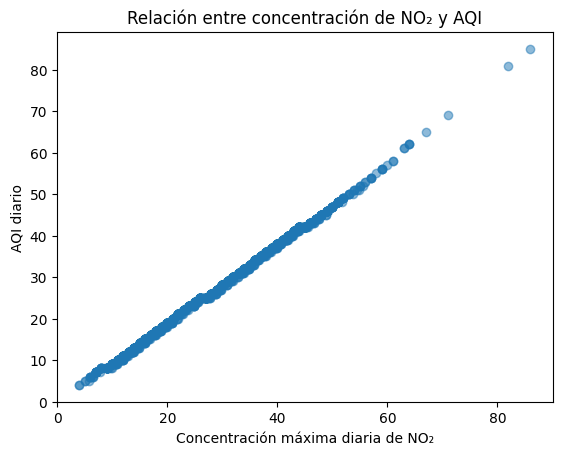

In [70]:
# Importamos matplotlib para crear gráficos
import matplotlib.pyplot as plt

# Creamos un diagrama de dispersión, como se vió en clase
plt.scatter(X, y, alpha=0.5)
plt.xlabel("Concentración máxima diaria de NO₂")
plt.ylabel("AQI diario")

plt.title("Relación entre concentración de NO₂ y AQI")

plt.show()

In [71]:
#hacemos predicciónes
y_pred = modelo.predict(X_test) #aca le doy los datos que no uso para entrenarse
#entonces creo una lista de predicciones

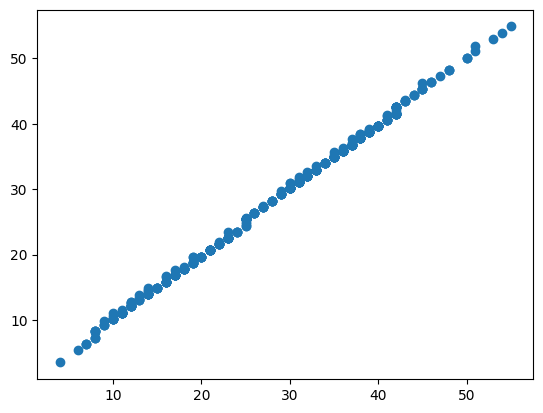

In [72]:
#creo una grafica de solo los puntos reales vs puntos predichos
plt.scatter(x=y_test, y=y_pred)

In [73]:
# Importo las métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#calulo el error absoluto medio
mae = mean_absolute_error(y_test, y_pred)

#calculo la raíz del error cuadrático medio
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

#calculo el coeficiente de determinación
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.2678868849198018
RMSE: 0.3319004254171387
R²: 0.9991211157783192


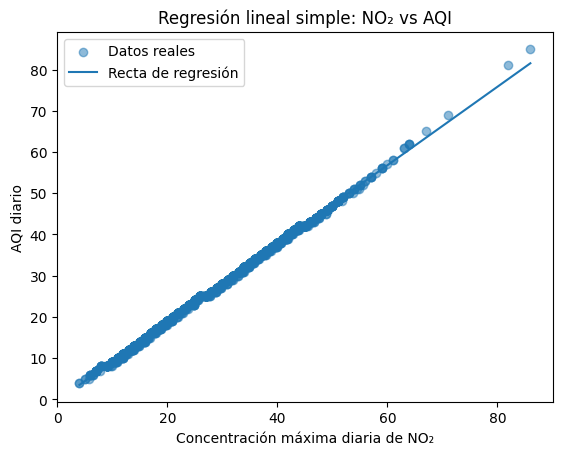

In [74]:
#Dibujo la recta de regresión final
X_ordenado = X.sort_values(
    by="Daily Max 1-hour NO2 Concentration"
)

# Predicciones para esos valores ordenados
y_linea = modelo.predict(X_ordenado)

# Datos reales
plt.scatter(X, y, alpha=0.5, label="Datos reales")

# Recta de regresión
plt.plot(X_ordenado, y_linea, label="Recta de regresión")

plt.xlabel("Concentración máxima diaria de NO₂")
plt.ylabel("AQI diario")
plt.title("Regresión lineal simple: NO₂ vs AQI")
plt.legend()

plt.show()